# 02 — Feature engineering\n\nThis notebook walks through the feature pipeline, demonstrates PSI calculation mechanics, and validates that the schema remains consistent after feature transformations.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_DIR)

from src.data_loader import load_training_data, load_drift_data, run_all_validations
from src.model import FeatureEngineer, compute_psi, _psi_bucket

In [2]:
data_dir = os.path.join(PROJECT_DIR, "data")
train_df, test_df = load_training_data(data_dir)
drift_df = load_drift_data(data_dir)
print(f"Train: {train_df.shape}, Test: {test_df.shape}, Drift: {drift_df.shape}")

Train: (5000, 20), Test: (1500, 20), Drift: (2000, 20)


## Derived features\n\nThe feature engineer adds four new columns:\n- **AvgMonthlySpend**: TotalCharges / tenure (handles zero-tenure edge case)\n- **tenure_bucket**: Lifecycle stage binning (0-12, 12-24, 24-48, 48-72)\n- **has_internet**: Binary flag for internet service\n- **num_services**: Count of active add-on services

In [3]:
fe = FeatureEngineer()
train_feat = fe.add_derived_features(train_df)

# Show new columns
new_cols = [c for c in train_feat.columns if c not in train_df.columns]
print(f"New columns: {new_cols}")
print(f"Shape: {train_df.shape} -> {train_feat.shape}")
train_feat[new_cols].head(10)

New columns: ['AvgMonthlySpend', 'tenure_bucket', 'has_internet', 'num_services']
Shape: (5000, 20) -> (5000, 24)


,AvgMonthlySpend,tenure_bucket,has_internet,num_services
0,41.468750,0-12,1,3
1,59.550000,0-12,1,2
2,95.362361,48-72,1,0
3,70.965000,0-12,1,0
4,81.712667,24-48,0,0
5,31.758333,24-48,1,3
6,26.909091,12-24,1,1
7,71.974595,24-48,1,1
8,111.258333,0-12,1,1
9,90.418197,48-72,1,4


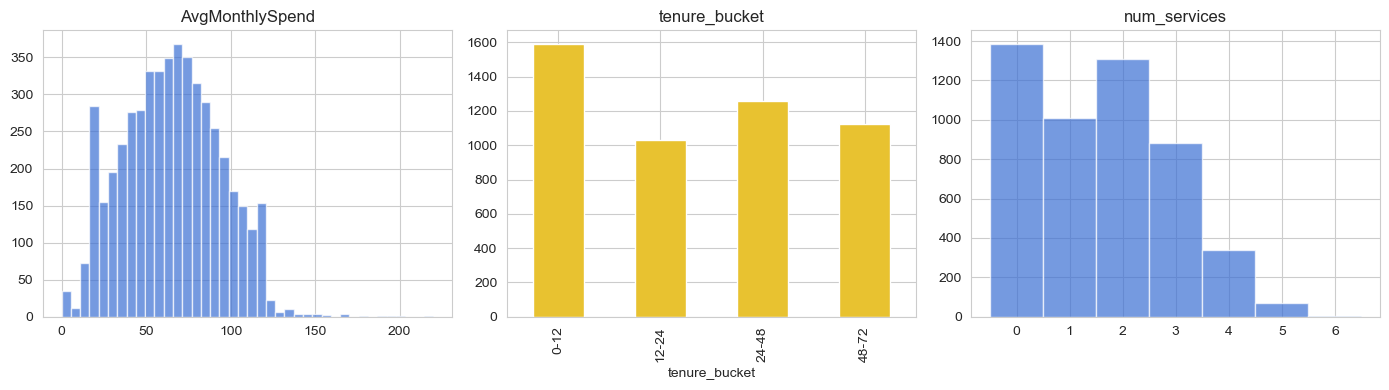

In [4]:
# Distribution of derived features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(train_feat["AvgMonthlySpend"], bins=40, color="#3B6FD4", alpha=0.7)
axes[0].set_title("AvgMonthlySpend")

train_feat["tenure_bucket"].value_counts().sort_index().plot.bar(ax=axes[1], color="#E8C230")
axes[1].set_title("tenure_bucket")

axes[2].hist(train_feat["num_services"], bins=range(8), color="#3B6FD4", alpha=0.7, align="left")
axes[2].set_title("num_services")

plt.tight_layout()
plt.show()

## Preprocessing pipeline\n\nThe `ColumnTransformer` applies StandardScaler to numeric features and OneHotEncoder to categorical features. Let us verify the output shape and column names.

In [5]:
preprocessor = fe.build_preprocessor()
X = train_feat.drop(columns=["Churn"])
X_transformed = preprocessor.fit_transform(X)

print(f"Input shape:  {X.shape}")
print(f"Output shape: {X_transformed.shape}")
print(f"Output type:  {type(X_transformed)}")

# Get feature names
num_names = preprocessor.transformers_[0][2]
cat_names = preprocessor.transformers_[1][1].get_feature_names_out()
all_names = list(num_names) + list(cat_names)
print(f"Total features: {len(all_names)}")

Input shape:  (5000, 23)
Output shape: (5000, 52)
Output type:  <class 'numpy.ndarray'>
Total features: 52


## PSI calculation walkthrough\n\nThe Population Stability Index measures how much a feature's distribution has shifted between two datasets. Here we step through the calculation for a single feature.

In [6]:
# Step-by-step PSI for tenure
col = "tenure"
bins = 10
eps = 1e-4

ref = train_df[col].values.astype(float)
cur = drift_df[col].values.astype(float)

breakpoints = np.linspace(min(ref.min(), cur.min()), max(ref.max(), cur.max()), bins + 1)
ref_pct = np.histogram(ref, bins=breakpoints)[0] / len(ref)
cur_pct = np.histogram(cur, bins=breakpoints)[0] / len(cur)

ref_pct = np.clip(ref_pct, eps, None)
cur_pct = np.clip(cur_pct, eps, None)

psi_per_bin = (cur_pct - ref_pct) * np.log(cur_pct / ref_pct)
total_psi = psi_per_bin.sum()

print(f"Feature: {col}")
print(f"Total PSI: {total_psi:.4f}")
print()

bin_df = pd.DataFrame({
    "Bin": [f"{breakpoints[i]:.0f}-{breakpoints[i+1]:.0f}" for i in range(bins)],
    "Ref %": np.round(ref_pct, 4),
    "Cur %": np.round(cur_pct, 4),
    "PSI contribution": np.round(psi_per_bin, 4),
})
bin_df

Feature: tenure
Total PSI: 1.9195



,Bin,Ref %,Cur %,PSI contribution
0,0-7,0.2110,0.3940,0.1143
1,7-14,0.1472,0.2240,0.0322
2,14-22,0.1196,0.1295,0.0008
3,22-29,0.0974,0.0880,0.0010
4,29-36,0.0810,0.0510,0.0139
5,36-43,0.0820,0.1135,0.0102
6,43-50,0.0500,0.0001,0.3101
7,50-58,0.0366,0.0001,0.2154
8,58-65,0.0336,0.0001,0.1949
9,65-72,0.1416,0.0001,1.0267


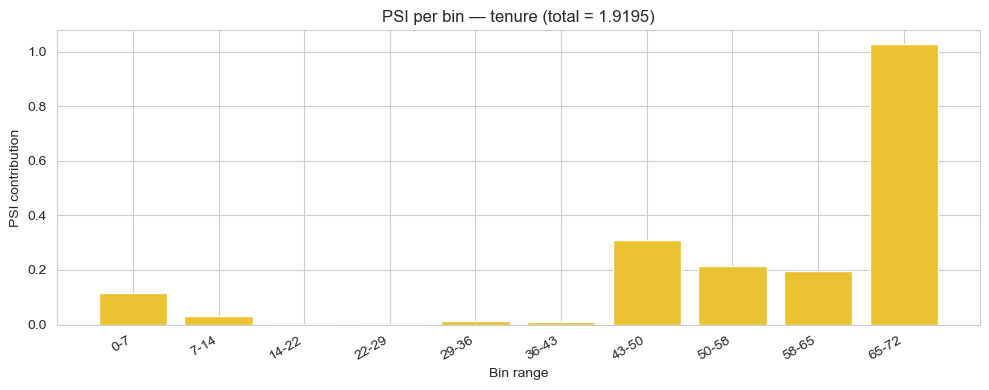

In [7]:
# Visualize bin-level PSI contributions
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(bin_df["Bin"], bin_df["PSI contribution"], color="#E8C230")
ax.set_xlabel("Bin range")
ax.set_ylabel("PSI contribution")
ax.set_title(f"PSI per bin — {col} (total = {total_psi:.4f})")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Full PSI comparison — all numeric features

In [8]:
# PSI for train vs test (should be low — same distribution)
psi_train_test = compute_psi(train_df, test_df)
# PSI for train vs drift (should be higher)
psi_train_drift = compute_psi(train_df, drift_df)

compare = pd.DataFrame({
    "Feature": list(psi_train_test.keys()),
    "PSI (train vs test)": [round(psi_train_test[k], 4) for k in psi_train_test],
    "PSI (train vs drift)": [round(psi_train_drift.get(k, 0), 4) for k in psi_train_test],
}).sort_values("PSI (train vs drift)", ascending=False)
compare

,Feature,PSI (train vs test),PSI (train vs drift)
1,tenure,0.0179,1.9195
3,TotalCharges,0.0106,0.6228
2,MonthlyCharges,0.0091,0.2794
0,SeniorCitizen,0.0006,0.0023
4,Churn,0.0000,0.0000


## Schema validation after feature engineering\n\nVerify that derived features do not introduce nulls or break expected constraints.

In [9]:
# Check for nulls in derived features
null_counts = train_feat[new_cols].isnull().sum()
print("Null counts in derived features:")
print(null_counts)
print()

# Verify no infinite values
inf_counts = np.isinf(train_feat.select_dtypes(include="number")).sum()
print("Infinite value counts:")
print(inf_counts[inf_counts > 0] if inf_counts.sum() > 0 else "None found")

Null counts in derived features:
AvgMonthlySpend    0
tenure_bucket      0
has_internet       0
num_services       0
dtype: int64

Infinite value counts:
None found


In [10]:
# Verify feature engineering produces consistent results across datasets
test_feat = fe.add_derived_features(test_df)
drift_feat = fe.add_derived_features(drift_df)

assert set(train_feat.columns) == set(test_feat.columns), "Column mismatch between train and test"
assert set(train_feat.columns) == set(drift_feat.columns), "Column mismatch between train and drift"
print("Schema consistency check passed across all three datasets")

Schema consistency check passed across all three datasets


## Feature importance preview\n\nQuick look at which raw features correlate most with churn, to validate that the feature engineering adds useful signal.

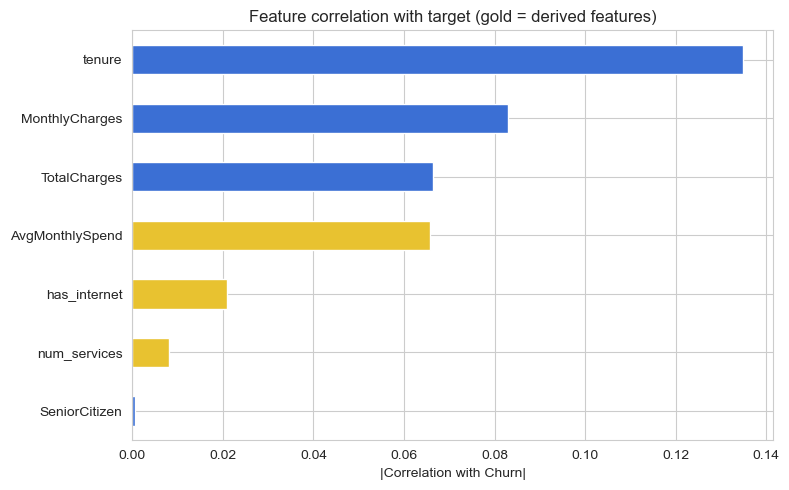

In [11]:
numeric_feat = train_feat.select_dtypes(include="number")
correlations = numeric_feat.corr()["Churn"].drop("Churn").abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
correlations.plot.barh(ax=ax, color=["#E8C230" if c in new_cols else "#3B6FD4" for c in correlations.index])
ax.set_xlabel("|Correlation with Churn|")
ax.set_title("Feature correlation with target (gold = derived features)")
plt.tight_layout()
plt.show()

## Summary\n\n- Feature engineering adds 4 derived features (AvgMonthlySpend, tenure_bucket, has_internet, num_services)\n- The preprocessing pipeline produces a consistent output shape across all datasets\n- PSI is low between train and test (same generation process) but high between train and drift (confirming shifted distributions)\n- No nulls or infinite values introduced by the feature pipeline\n- Schema consistency validated across train, test, and drift datasets